Task 2
Bayesian Change Point Detection
1. Import Libraries

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pymc as pm
import arviz as az

from scipy import stats

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


2. Load Dataset

In [3]:
df = pd.read_csv("../data/raw/BrentOilPrices.csv")

df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


3. Prepare Data

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.reset_index(drop=True, inplace=True)

df.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [5]:
#Check
df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[us]
 1   Price   9011 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 140.9 KB


,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


4. Plot Oil Prices

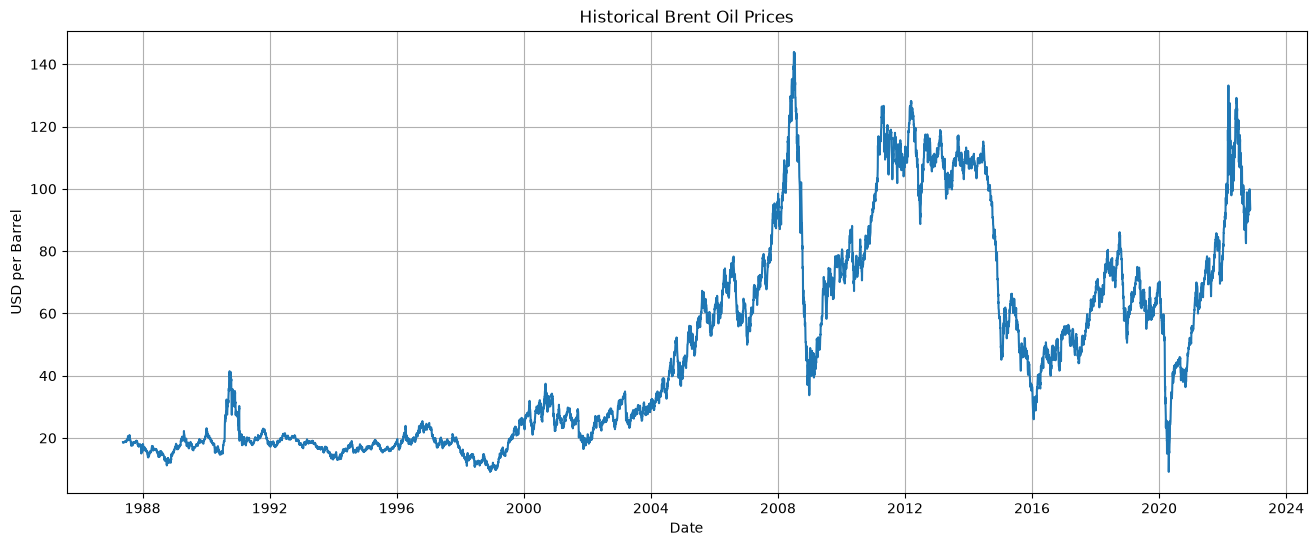

In [6]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"], df["Price"])

plt.title("Historical Brent Oil Prices")

plt.xlabel("Date")

plt.ylabel("USD per Barrel")

plt.grid(True)

plt.show()

### Interpretation of Historical Brent Oil Prices

The historical Brent oil price series (1987–2022) exhibits significant long-term trends, abrupt price shocks, and periods of heightened volatility, indicating that the market has experienced multiple structural changes over time.

Key observations include:

- **1987–2003:** Oil prices remained relatively stable, fluctuating mostly between **$10 and $35 per barrel**, with only moderate short-term volatility.
- **2004–2008:** A strong upward trend is observed, culminating in a peak of approximately **$145 per barrel** during the 2008 global commodity boom.
- **2008–2009:** Prices experienced a dramatic collapse following the **Global Financial Crisis**, falling to below **$40 per barrel**.
- **2011–2014:** Brent prices recovered and remained relatively high, generally trading above **$100 per barrel**, reflecting increased global demand and geopolitical tensions.
- **2014–2016:** A substantial decline occurred due to excess oil supply and OPEC production decisions, with prices dropping to nearly **$30 per barrel**.
- **2020:** The most pronounced decline in the series occurred during the **COVID-19 pandemic**, when global lockdowns sharply reduced oil demand.
- **2021–2022:** Prices rebounded rapidly, exceeding **$120 per barrel**, influenced by economic recovery, supply chain disruptions, and geopolitical events such as the Russia–Ukraine conflict.

Overall, the time series demonstrates several periods where the underlying behavior of oil prices changes substantially. These visible shifts suggest the presence of **structural breakpoints (change points)**, making the dataset well suited for Bayesian Change Point Analysis. Identifying these change points will help determine when significant market regime changes occurred and quantify how major geopolitical and economic events influenced Brent oil prices.